# Single Neuron Regression Analysis :)

In [25]:
import os
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


In [26]:
significant_results = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/directional_linear_regression_on_single_neurons.pkl')
significant_results = significant_results[significant_results['p_value'] < 0.05]
significant_results.shape

(2781, 7)

## Simple Visualization

### Bar Plot

In [10]:
from analyses.linear_regression.run_single_neuron_regressions import plot_single_neuron_profile
#
# for neuron_id in significant_results['NeuronID'].unique():
#     plot_single_neuron_profile(significant_results, neuron_id)

### Count Plot

In [19]:
best_monkey_df = significant_results.sort_values('R-squared', ascending=False).drop_duplicates('NeuronID')
plt.figure(figsize=(10, 5))
sns.countplot(data=best_monkey_df, x='Source_Monkey', order=best_monkey_df['Source_Monkey'].value_counts().index)
plt.title("Most-explained Source Monkey per neuron (best R²)")
plt.xlabel("Source Monkey")
plt.ylabel("Neuron Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Representing each neuron as 54-dimensional vector
6 behaviors x 9 source monkeys
(not all of these r-squared values would be p-value with < 0.05 (so they probably didn't pass the filtering) so they would just be 0 here)

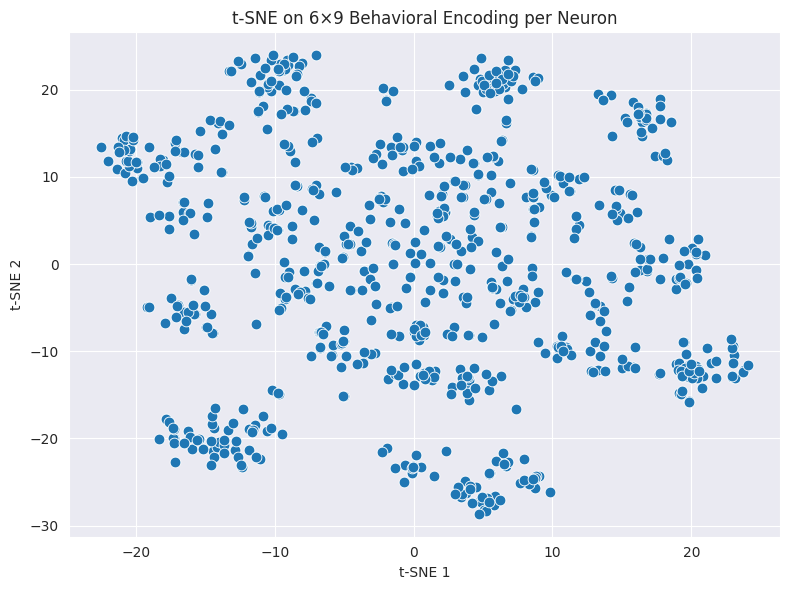

In [27]:
# Step 1: 먼저 전체 significant result를 behavior × source_monkey 조합으로 정리
filtered_df = significant_results.sort_values('R-squared', ascending=False)

# Step 2: pivot (NeuronID × [Behavior|SourceMonkey] 조합 → column 이름을 합쳐서 사용)
filtered_df['Behavior_Source'] = filtered_df['Behavior'] + '__' + filtered_df['Source_Monkey']

pivot_df = filtered_df.pivot(index='NeuronID', columns='Behavior_Source', values='R-squared').fillna(0)

# Optional: thresholding
pivot_df[pivot_df < 0.05] = 0

# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pivot_df)
# t-sne
tsne = TSNE(n_components=2, perplexity=50, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(scaled_data)

# 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], s=60)
plt.title("t-SNE on 6×9 Behavioral Encoding per Neuron")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

### PCA on 54-dim Vector

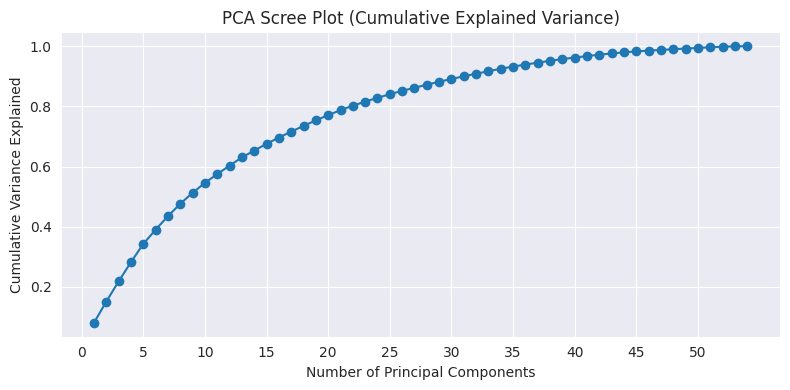

In [28]:
# PCA fitting for 54 vector
pca = PCA()
pca.fit(scaled_data)

# Explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Scree plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_var) + 1), cumulative_var, marker='o')
plt.title("PCA Scree Plot (Cumulative Explained Variance)")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.xticks(range(0, 55, 5))
plt.grid(True)
plt.tight_layout()
plt.show()


### Reducing dimensions and then t-SNE

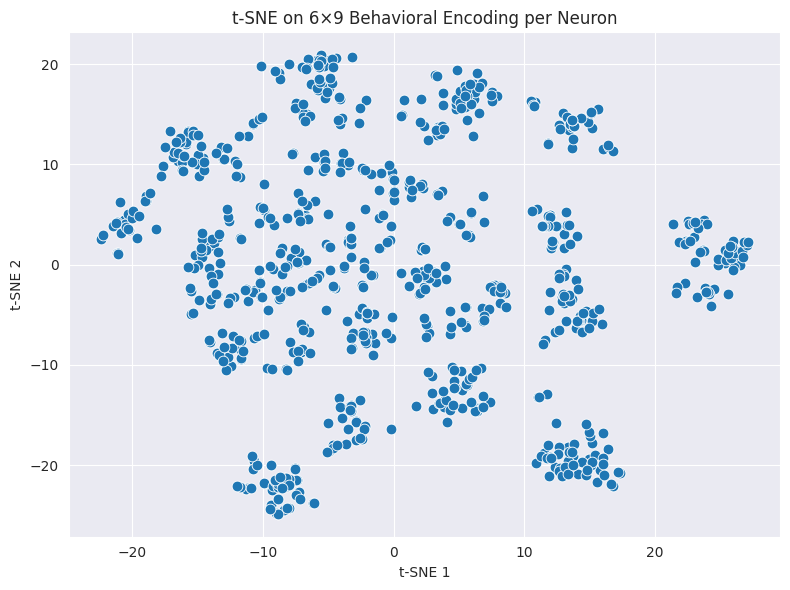

In [29]:
 # now, reduce the dimensions to 20 and then do t-sne
pca = PCA(n_components=25, random_state=42)
pca_reduced = pca.fit_transform(scaled_data)

# 2. t-SNE on PCA-reduced data
tsne = TSNE(n_components=2, perplexity=50, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(pca_reduced)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], s=60)
plt.title("t-SNE on 6×9 Behavioral Encoding per Neuron")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

# Get largest R-sq source monkey for each behavior and vectorize (6-dim)

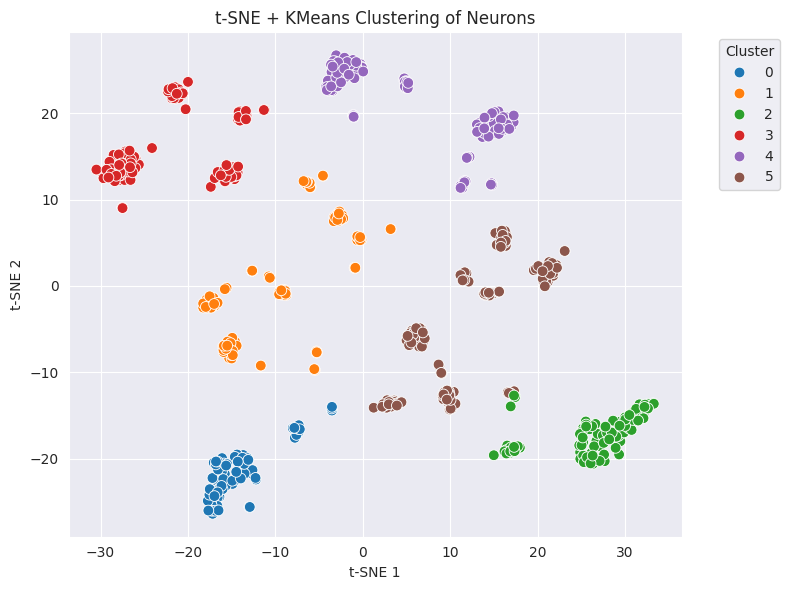

In [30]:
filtered_df = (
        significant_results
        .sort_values('R-squared', ascending=False)
        .drop_duplicates(['NeuronID', 'Behavior'])
    )
filtered_df = filtered_df.reset_index(drop=True)
# Step 1: pivot (NeuronID × Behavior) wide format 만들기
pivot_df = filtered_df.pivot(index='NeuronID', columns='Behavior', values='R-squared').fillna(0)

# pivot_df[pivot_df < 0.05] = 0
pivot_df = pivot_df[(pivot_df > 0).sum(axis=1) >= 2]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(pivot_df)
# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(scaled_data)

# KMeans clustering
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tsne_coords)

# add cluster colors to t-sne plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE + KMeans Clustering of Neurons")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

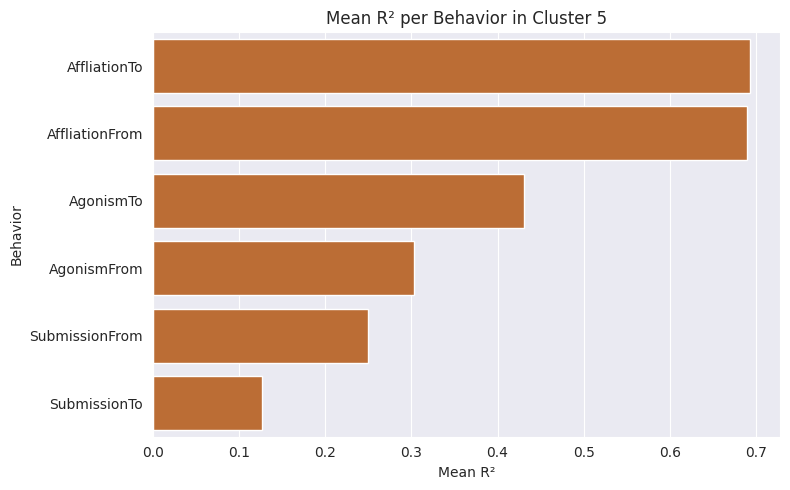

In [42]:
cluster_series = pd.Series(cluster_labels, index=pivot_df.index, name='Cluster')
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_series

# 2. Exctract specific cluster
cluster_5 = pivot_df_clustered[pivot_df_clustered['Cluster'] == 5].drop(columns='Cluster')

# 3. Get avg R² for each behavior
mean_r2 = cluster_5.mean().sort_values(ascending=False)

# 4. Visualize with bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=mean_r2.values, y=mean_r2.index, color='chocolate')
plt.title("Mean R² per Behavior in Cluster 5")
plt.xlabel("Mean R²")
plt.ylabel("Behavior")
plt.tight_layout()
plt.show()